In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
CURRENT_DIRECTORY =  os.getcwd()
SRC_DIRECTORY = Path(CURRENT_DIRECTORY).parents[1]
print(SRC_DIRECTORY)

BASE_DATASET_PATH = Path(SRC_DIRECTORY).parents[0]
BASE_DATASET_PATH = BASE_DATASET_PATH / "datasets"
print(BASE_DATASET_PATH)

/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/src
/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/datasets


#### Resident density

In [3]:
residential_2020_filepath = Path(BASE_DATASET_PATH / "singapore_data/cleaned_data/2020_age_group_planning_area_subzone.xlsx")

residential_data_2020 = pd.read_excel(residential_2020_filepath, sheet_name = "subzone")

In [4]:
residential_data_2020["planning_area"] = residential_data_2020["planning_area"].ffill()
residential_data_2020.tail()

,planning_area,subzone,total,0 - 4,5 - 9,10 - 14,15 - 19,20 - 24,25 - 29,30 - 34,...,50 - 54,55 - 59,60 - 64,65 - 69,70 - 74,75 - 79,80 - 84,85 - 89,90 & over,total_above_60
383,yishun,springleaf,4370,130,170,250,300,320,410,250,...,290,370,350,290,240,120,80,30,20,1130
384,yishun,yishun central,2620,100,120,150,130,170,220,200,...,190,210,170,150,80,50,30,20,10,510
385,yishun,yishun east,60670,4270,4410,3270,2970,3300,4220,5420,...,3850,4190,3440,2590,1670,730,510,250,120,9310
386,yishun,yishun south,42240,1930,1690,1920,2090,2500,3600,3720,...,2890,3690,3250,2570,1740,830,580,320,170,9460
387,yishun,yishun west,53910,1780,1990,2440,2790,3410,3810,3590,...,4330,4840,4500,3580,2320,1280,880,480,240,13280


In [5]:
subzones_2019_filepath = Path(BASE_DATASET_PATH / "singapore_data/data_gov/masterplan_2019/subzone_classifications_2019.csv")

subzones_2019 = pd.read_csv(subzones_2019_filepath)

# lower() the values
subzones_2019 = subzones_2019.map(lambda s: s.lower() if isinstance(s, str) else s)
subzones_2019.head()

,subzone_n,pln_area_n,beach_area,business_2,educational_institution,utility,special_use,waterbody,port_/_airport,park,...,reserve_site,white,place_of_worship,business_2_-_white,hotel,residential_/_institution,business_park_-_white,business_park,agriculture,pri_classification
0,ang mo kio town centre,ang mo kio,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,3618.378339,0.0,3158.691819,0.0,0.0,0.0,0.0,0.0,0.0,residential
1,cheng san,ang mo kio,0.0,0.0,69354.001638,5449.975328,0.0,0.0,0.0,0.000000,...,66989.017889,0.0,2670.252332,0.0,0.0,0.0,0.0,0.0,0.0,residential
2,chong boon,ang mo kio,0.0,0.0,99001.720328,2889.883781,0.0,0.0,0.0,46794.171931,...,0.000000,0.0,3705.863128,0.0,0.0,0.0,0.0,0.0,0.0,residential
3,kebun bahru,ang mo kio,0.0,0.0,81815.723948,5675.106350,0.0,0.0,0.0,214378.840299,...,0.000000,0.0,2325.137686,0.0,0.0,0.0,0.0,0.0,0.0,residential
4,sembawang hills,ang mo kio,0.0,0.0,0.000000,7547.350060,0.0,0.0,0.0,24545.949929,...,61267.743903,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,residential


In [6]:
# check if the planning area and subzone name of both datasets match

# 1. Perform the left join
# subzones_2019 is the 'left' table because it contains all pairs
check_df = pd.merge(
    subzones_2019, 
    residential_data_2020, 
    left_on=['subzone_n', 'pln_area_n'], 
    right_on=['subzone', 'planning_area'], 
    how='left',
    indicator=True
)

# 2. Identify the pairs that are MISSING in residential_data_2020
missing_in_res = check_df[check_df['_merge'] == 'left_only']

# 3. Identify the pairs that MATCH in both
matching_pairs = check_df[check_df['_merge'] == 'both']

print(f"Total pairs in Subzones 2019: {len(subzones_2019)}")
print(f"Matches found: {len(matching_pairs)}")
print(f"Pairs missing in Residential 2020: {len(missing_in_res)}")
if len(missing_in_res) != 0:
    print(f"Pairs missing in Residential 2020: {missing_in_res}")

Total pairs in Subzones 2019: 332
Matches found: 332
Pairs missing in Residential 2020: 0


Density per hectare = $\frac{residential\ number \times 10000}{Area\ in \ m^2}$

In [7]:
# calculate the residential density of each subzone

# left join to keep all subzones from the 2019 master list
merged_total_density_df = pd.merge(
    subzones_2019, 
    residential_data_2020[['subzone', 'planning_area', 'total', 'total_above_60']], 
    left_on=['subzone_n', 'pln_area_n'], 
    right_on=['subzone', 'planning_area'], 
    how='left'
)
# We fill NaN totals with 0 so the calculation doesn't fail
merged_total_density_df['total'] = merged_total_density_df['total'].fillna(0)
merged_total_density_df['total_above_60'] = merged_total_density_df['total_above_60'].fillna(0)

# Identify and sum all columns that contain 'residential' in the name
residential_cols = [col for col in merged_total_density_df.columns if 'residential' in col]
merged_total_density_df['total_residential_area'] = merged_total_density_df[residential_cols].sum(axis=1)

# Calculate Density per Hectare
# Formula: (residential number * 10000) / Area in m2
merged_total_density_df['density_per_ha'] = (merged_total_density_df['total'] * 10000) / merged_total_density_df['total_residential_area']

# Replace infinity values if area was 0
merged_total_density_df['density_per_ha'] = merged_total_density_df['density_per_ha'].replace([np.inf, -np.inf], 0)

display(merged_total_density_df[['pln_area_n', 'subzone_n', 'total', 'total_residential_area', 'density_per_ha']].head())

,pln_area_n,subzone_n,total,total_residential_area,density_per_ha
0,ang mo kio,ang mo kio town centre,4810,220396.020499,218.243505
1,ang mo kio,cheng san,28070,614506.409350,456.789377
2,ang mo kio,chong boon,26500,544706.259566,486.500743
3,ang mo kio,kebun bahru,22620,563585.291723,401.358948
4,ang mo kio,sembawang hills,6850,554266.820570,123.586687


In [8]:
merged_total_density_df["density_per_ha"] = merged_total_density_df["density_per_ha"].fillna(0)
df = merged_total_density_df.sort_values("density_per_ha", ascending = False)
df[['pln_area_n', 'subzone_n', 'total', 'total_residential_area', 'density_per_ha']]

,pln_area_n,subzone_n,total,total_residential_area,density_per_ha
177,outram,people's park,290,0.001252,2.316001e+09
210,queenstown,national university of s'pore,240,0.003253,7.378667e+08
226,rochor,little india,3270,31642.338720,1.033426e+03
175,outram,chinatown,10490,115219.825786,9.104336e+02
134,jurong west,wenya,8280,101519.967978,8.156031e+02
...,...,...,...,...,...
98,downtown core,phillip,10,0.000000,0.000000e+00
236,seletar,seletar aerospace park,20,0.000000,0.000000e+00
235,seletar,seletar,280,0.000000,0.000000e+00
234,seletar,pulau punggol timor,0,0.000000,0.000000e+00


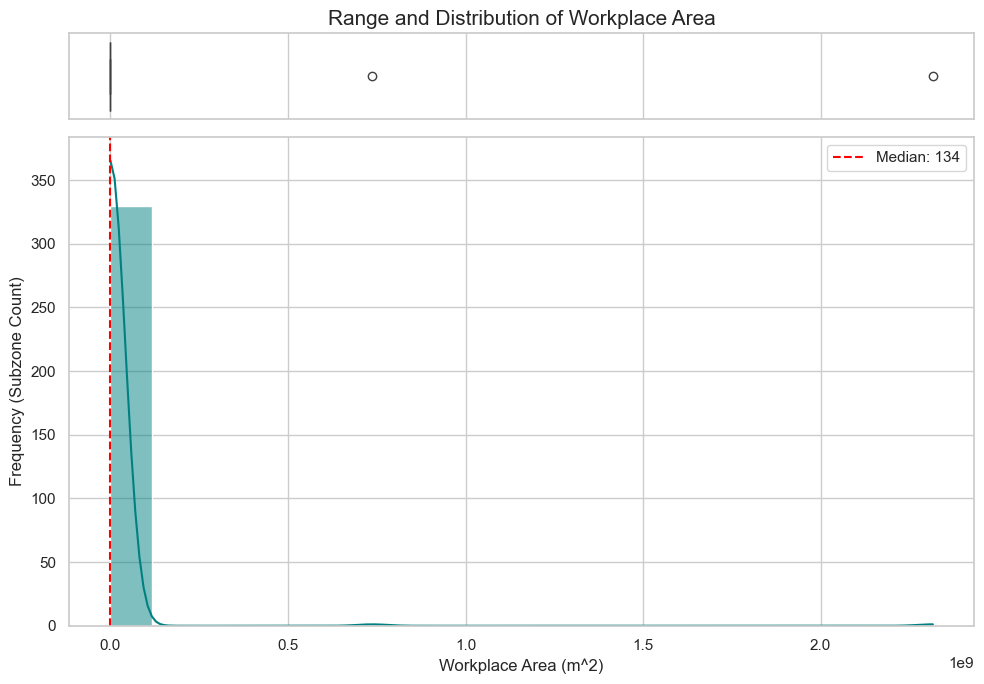

In [9]:
# Set the style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots (1 row, 2 columns - or stacked)
# We will use a "Gridspec" style approach for a top-bottom view
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 7))

# 1. Plot the Range (Boxplot) on the top axis
sns.boxplot(x=merged_total_density_df["density_per_ha"], ax=ax_box, color="lightseagreen")
ax_box.set(xlabel='') # Hide xlabel for the top plot
ax_box.set_title('Range and Distribution of Workplace Area', fontsize=15)

# 2. Plot the Distribution (Histogram + KDE) on the bottom axis
sns.histplot(merged_total_density_df["density_per_ha"], ax=ax_hist, kde=True, color="teal", bins=20)

# Labeling
plt.xlabel('Workplace Area (m^2)', fontsize=12)
plt.ylabel('Frequency (Subzone Count)', fontsize=12)

# Add a vertical line for the Median on the histogram
median_val = merged_total_density_df["density_per_ha"].median()
ax_hist.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:,.0f}')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
descending_total_density = merged_total_density_df.sort_values(by = "density_per_ha", ascending = False)
display(descending_total_density[["subzone_n", "pln_area_n", "total", "total_residential_area", "density_per_ha"]].head(8))

save_to_filepath = Path(BASE_DATASET_PATH / "singapore_data/cleaned_data/resident_density_2020.csv")
descending_total_density.to_csv(save_to_filepath)

,subzone_n,pln_area_n,total,total_residential_area,density_per_ha
177,people's park,outram,290,0.001252,2.316001e+09
210,national university of s'pore,queenstown,240,0.003253,7.378667e+08
226,little india,rochor,3270,31642.338720,1.033426e+03
175,chinatown,outram,10490,115219.825786,9.104336e+02
134,wenya,jurong west,8280,101519.967978,8.156031e+02
58,saujana,bukit panjang,25920,359889.326428,7.202214e+02
238,sembawang central,sembawang,34800,488491.882146,7.123967e+02
76,peng siang,choa chu kang,34720,496286.705139,6.995956e+02


Encoding resident density: 
- 0 residents -> 0
- 0 to 10 residents -> 1
- 10 to 50 residents -> 2
- 50 to 100 residents -> 3
- 100 to 1000 residents -> 4

There are 3 points of outlier that needs to be checked.
- people's park (0.09135 $km^2$)
- national university of s'pore (1.753 $km^2$)
- little india (0.2783 $km^2$)

landsizes base on: https://www.citypopulation.de/en/singapore/admin/

There are multiple subzones with residents but no recorded residential areas. They will be categorised as such:
1. subzones with 10 or less residents: 0 to 10 residents
2. subzones with 10 to 50 residents: 10 to 50 residents
3. subzones with 50 or more residents: 50 to 100 residents

Subzones with more than 100 residents but with no recorded residential areas will be assigned to the 50 to 100 residents category. These subzones have less established residential areas so its characteristics might differ from subzones with larger residential areas. This is also to avoid affecting the accuracy of prediction for subzones with more than 1000 residents.

People's park and national university of s'pore will be assigned to the 50 to 100 residents category. This is because both has a resident size of <300, People's park residents are mostly located within the people's park complex and national univeristy of singapore's residents would be students and staff living in accomodations throughout the university. 

little india will be assigned to the 100 to 1000 residents category as the subzone has a small area but more than 3000 residents

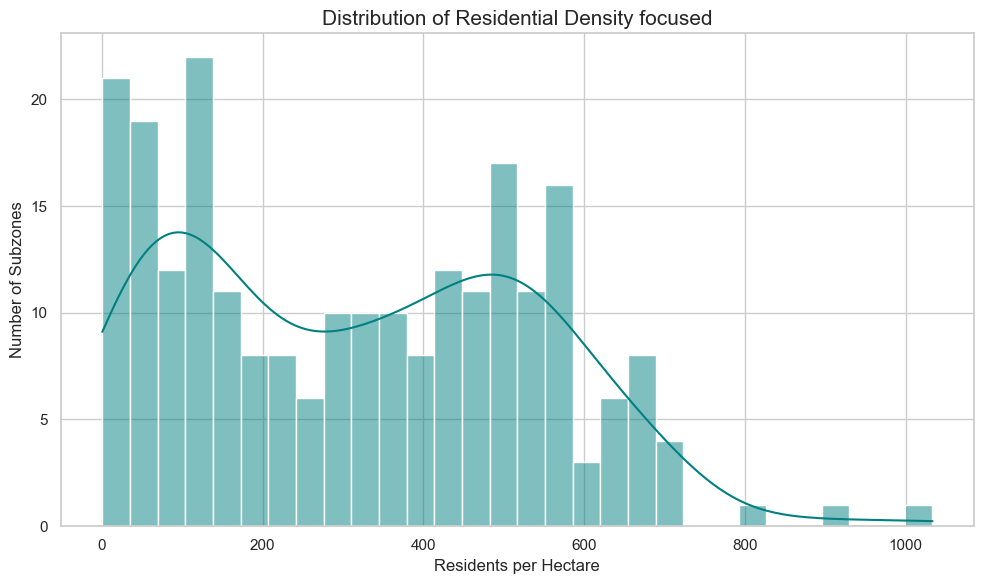

In [11]:
focused_df = merged_total_density_df[
    (merged_total_density_df['density_per_ha'] > 0) & 
    (merged_total_density_df['density_per_ha'] <= 2000)
]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(focused_df['density_per_ha'], bins=30, kde=True, color='teal')

plt.title('Distribution of Residential Density focused', fontsize=15)
plt.xlabel('Residents per Hectare', fontsize=12)
plt.ylabel('Number of Subzones', fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
# encode the resident density classifications for prediction
bins = [-0.1, 0, 10, 50, 100, float('inf')]
labels = [0, 1, 2, 3, 4]

merged_total_density_df["resident_density_encoding"] = pd.cut(merged_total_density_df["density_per_ha"], bins = bins, labels = labels).astype(int)

# Refined Logic for subzones with 0 density but >0 total residents
cond1 = (merged_total_density_df["resident_density_encoding"] == 0) & (merged_total_density_df["total"] > 0) & (merged_total_density_df["total"] <= 10)
cond2 = (merged_total_density_df["resident_density_encoding"] == 0) & (merged_total_density_df["total"] > 10) & (merged_total_density_df["total"] <= 50)
cond3 = (merged_total_density_df["resident_density_encoding"] == 0) & (merged_total_density_df["total"] > 50)

# Define the values to assign for each condition
choices = [1, 2, 3]

# Apply the correction
merged_total_density_df["resident_density_encoding"] = np.select(
    [cond1, cond2, cond3], 
    choices, 
    default=merged_total_density_df["resident_density_encoding"]
)


## manual overrides for specific subzones
density_manual_overrides = {
    "people's park": 3,
    "national university of s'pore": 3,
}

## apply the manual mapping
for subzone, new_encoding in density_manual_overrides.items():
    condition = merged_total_density_df['subzone'].str.lower() == subzone.lower()
    merged_total_density_df.loc[condition, "resident_density_encoding"] = new_encoding

In [13]:
descending_total_density = merged_total_density_df.sort_values(by = "density_per_ha", ascending = False)
descending_total_density = descending_total_density[['subzone_n', 'pln_area_n', "pri_classification", "total", "total_above_60",
                                                    "total_residential_area", "density_per_ha", "resident_density_encoding"]].copy()

save_to_filepath = Path(BASE_DATASET_PATH / "singapore_data/cleaned_data/subzone_classifications_2020.csv")
descending_total_density.to_csv(save_to_filepath)

save_to_filepath = Path(BASE_DATASET_PATH / "singapore_data/cleaned_data/resident_density_2020.csv")
descending_total_density.to_csv(save_to_filepath)
descending_total_density

,subzone_n,pln_area_n,pri_classification,total,total_above_60,total_residential_area,density_per_ha,resident_density_encoding
177,people's park,outram,commercial,290,100,0.001252,2.316001e+09,3
210,national university of s'pore,queenstown,educational institution,240,0,0.003253,7.378667e+08,3
226,little india,rochor,commercial,3270,1130,31642.338720,1.033426e+03,4
175,chinatown,outram,commercial,10490,2750,115219.825786,9.104336e+02,4
134,wenya,jurong west,business 2,8280,1250,101519.967978,8.156031e+02,4
...,...,...,...,...,...,...,...,...
98,phillip,downtown core,commercial,10,0,0.000000,0.000000e+00,1
236,seletar aerospace park,seletar,port / airport,20,0,0.000000,0.000000e+00,2
235,seletar,seletar,reserve site,280,40,0.000000,0.000000e+00,3
234,pulau punggol timor,seletar,reserve site,0,0,0.000000,0.000000e+00,0


#### Resident >60 density
Proportion per 1000 residents

proportion of above 60 residents = $\frac{residents\ above\ 60}{total\ subzone\ residents} \times 1000$

In [28]:
merged_total_density_df['above_60_proportion'] = (merged_total_density_df['total_above_60'] / merged_total_density_df['total']) * 1000

# Replace infinity values if area was 0
merged_total_density_df['above_60_proportion'] = merged_total_density_df['above_60_proportion'].replace([np.inf, -np.inf], 0)
merged_total_density_df["above_60_proportion"] = merged_total_density_df["above_60_proportion"].fillna(0)

above_60_df = merged_total_density_df.sort_values("above_60_proportion", ascending = False)
above_60_df = above_60_df[['pln_area_n', 'subzone_n', 'total', 'total_above_60', 'above_60_proportion']].copy()

save_to_filepath = Path(BASE_DATASET_PATH / "singapore_data/cleaned_data/above_60_proportion_2020.csv")
above_60_df.to_csv(save_to_filepath)
display(above_60_df)

,pln_area_n,subzone_n,total,total_above_60,above_60_proportion
180,pasir ris,loyang west,220,200,909.090909
121,jurong east,lakeside (leisure),1070,510,476.635514
176,outram,pearl's hill,6120,2730,446.078431
225,rochor,kampong glam,120,50,416.666667
138,kallang,crawford,8380,3480,415.274463
...,...,...,...,...,...
249,sengkang,lorong halus north,0,0,0.000000
245,sembawang,the wharves,0,0,0.000000
244,sembawang,senoko south,30,0,0.000000
243,sembawang,senoko north,10,0,0.000000


#### Ethnicity
Proportion of each ethnicity per 1000 resident

In [15]:
ethnicity_2020_filepath = Path(BASE_DATASET_PATH / "singapore_data/cleaned_data/ethnicity_combined.xlsx")

ethnicity_2020 = pd.read_excel(ethnicity_2020_filepath, sheet_name = "2020")

In [16]:
ethnicity_2020["planning_area"] = ethnicity_2020["planning_area"].ffill()
ethnicity_2020

,planning_area,subzone,total,male_total,female_total,total_chinese,male_chinese,female_chinese,total_malays,male_malays,female_malays,total_indians,male_indians,female_indians,total_others,male_others,female_others
0,total,total,4044210,1977560,2066650,3006770,1461340,1545430,545500,271330,274170,362270,185570,176710,129670,59320,70350
1,ang mo kio,total,162280,77570,84700,134350,64050,70300,11140,5480,5660,12810,6350,6470,3970,1690,2280
2,ang mo kio,ang mo kio town centre,4810,2260,2550,4140,1950,2200,140,60,80,370,170,200,160,80,80
3,ang mo kio,cheng san,28070,13480,14600,23240,11120,12120,1940,960,980,2280,1150,1130,610,250,370
4,ang mo kio,chong boon,26500,12860,13640,21860,10590,11270,1830,920,900,2240,1130,1110,580,220,360
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,yishun,springleaf,4370,2180,2190,4010,2000,2010,40,20,20,220,110,100,110,50,60
384,yishun,yishun central,2620,1290,1340,2300,1130,1170,140,70,80,140,70,70,50,20,30
385,yishun,yishun east,60670,30030,30640,40290,19960,20330,12670,6260,6410,6110,3160,2940,1600,650,950
386,yishun,yishun south,42240,20670,21580,30680,15000,15680,6230,3100,3130,4230,2130,2090,1110,440,670


In [17]:
# check if the planning area and subzone name of both datasets match

# 1. Perform the left join
# subzones_2019 is the 'left' table because it contains all pairs
check_df = pd.merge(
    subzones_2019, 
    ethnicity_2020, 
    left_on=['subzone_n', 'pln_area_n'], 
    right_on=['subzone', 'planning_area'], 
    how='left',
    indicator=True
)

# 2. Identify the pairs that are MISSING in ethnicity_2020
missing_in_res = check_df[check_df['_merge'] == 'left_only']

# 3. Identify the pairs that MATCH in both
matching_pairs = check_df[check_df['_merge'] == 'both']

print(f"Total pairs in Subzones 2019: {len(subzones_2019)}")
print(f"Matches found: {len(matching_pairs)}")
print(f"Pairs missing in Residential 2020: {len(missing_in_res)}")
if len(missing_in_res) != 0:
    print(f"Pairs missing in Residential 2020: {missing_in_res}")

Total pairs in Subzones 2019: 332
Matches found: 332
Pairs missing in Residential 2020: 0


In [18]:
columns_of_interest = ["total_chinese", "total_malays", "total_indians", "total_others"]

# calculate the residential density of each subzone

# left join to keep all subzones from the 2019 master list
merged_ethnicity_density_df = pd.merge(
    subzones_2019, 
    ethnicity_2020[['subzone', 'planning_area', "total", "total_chinese", "total_malays", "total_indians", "total_others"]], 
    left_on=['subzone_n', 'pln_area_n'],
    right_on=['subzone', 'planning_area'],
    how='left'
)
# We fill NaN totals with 0 so the calculation doesn't fail
merged_ethnicity_density_df[columns_of_interest] = merged_ethnicity_density_df[columns_of_interest].fillna(0)


# Identify and sum all columns that contain 'residential' in the name
residential_cols = [col for col in merged_ethnicity_density_df.columns if 'residential' in col]
merged_ethnicity_density_df['total_residential_area'] = merged_ethnicity_density_df[residential_cols].sum(axis=1)

# Calculate proportion of ethnicity per 1000 residents
merged_ethnicity_density_df['chinese_proportion'] = (merged_ethnicity_density_df['total_chinese'] / merged_ethnicity_density_df['total']) * 1000
merged_ethnicity_density_df['malays_proportion'] = (merged_ethnicity_density_df['total_malays'] / merged_ethnicity_density_df['total']) * 1000
merged_ethnicity_density_df['indians_proportion'] = (merged_ethnicity_density_df['total_indians']/ merged_ethnicity_density_df['total']) * 1000
merged_ethnicity_density_df['others_proportion'] = (merged_ethnicity_density_df['total_others']/ merged_ethnicity_density_df['total']) * 1000

# Replace infinity values if area was 0
# merged_ethnicity_density_df['density_proportion'] = merged_ethnicity_density_df['density_proportion'].replace([np.inf, -np.inf], 0)

merged_ethnicity_density_df = merged_ethnicity_density_df[['pln_area_n', 'subzone_n', "total", "chinese_proportion", 
                                                           "malays_proportion", "indians_proportion", "others_proportion"]].copy()
merged_ethnicity_density_df = merged_ethnicity_density_df.fillna(0)
display(merged_ethnicity_density_df.head(20))

save_to_filepath = Path(BASE_DATASET_PATH / "singapore_data/cleaned_data/ethnicity_proportion_2020.csv")
merged_ethnicity_density_df.to_csv(save_to_filepath)

,pln_area_n,subzone_n,total,chinese_proportion,malays_proportion,indians_proportion,others_proportion
0,ang mo kio,ang mo kio town centre,4810,860.706861,29.106029,76.923077,33.264033
1,ang mo kio,cheng san,28070,827.930175,69.112932,81.225508,21.731386
2,ang mo kio,chong boon,26500,824.905660,69.056604,84.528302,21.886792
3,ang mo kio,kebun bahru,22620,827.144120,80.459770,70.291777,22.546419
4,ang mo kio,sembawang hills,6850,890.510949,10.218978,67.153285,32.116788
5,ang mo kio,shangri-la,15960,773.809524,110.275689,92.731830,23.182957
6,ang mo kio,tagore,7950,900.628931,8.805031,62.893082,27.672956
7,ang mo kio,townsville,21140,821.192053,68.117313,83.254494,27.909177
8,ang mo kio,yio chu kang,20,0.000000,0.000000,0.000000,0.000000
9,ang mo kio,yio chu kang east,4200,890.476190,14.285714,66.666667,28.571429


#### Workplace classification

In [19]:
# read from the subzone_classifications csv created from the extracting_landuse_type notebook
workplace_filepath = Path(BASE_DATASET_PATH / "singapore_data/data_gov/masterplan_2019/subzone_classifications_2019_edited.csv")

subzone_workplace_df = pd.read_csv(workplace_filepath)

In [20]:
subzone_workplace_df.columns

Index(['subzone_n', 'pln_area_n', 'beach_area', 'business_2',
       'educational_institution', 'utility', 'special_use', 'waterbody',
       'port_/_airport', 'park', 'road', 'business_1_-_white', 'commercial',
       'light_rapid_transit', 'transport_facilities', 'health_&_medical_care',
       'commercial_/_institution', 'business_1', 'residential',
       'sports_&_recreation', 'commercial_&_residential', 'mass_rapid_transit',
       'civic_&_community_institution', 'open_space',
       'residential_with_commercial_at_1st_storey', 'cemetery', 'reserve_site',
       'white', 'place_of_worship', 'business_2_-_white', 'hotel',
       'residential_/_institution', 'business_park_-_white', 'business_park',
       'agriculture', 'pri_classification', 'total_residential_area',
       'total_workplace_area'],
      dtype='object')

In [21]:
workplace_cols = [col for col in subzone_workplace_df.columns if 'business' in col]
display(workplace_cols)

['business_2',
 'business_1_-_white',
 'business_1',
 'business_2_-_white',
 'business_park_-_white',
 'business_park']

There are 3 types of workplace classification in singapore.
- business 1: Clean industry, light industry, public utilities (logistics, warehousing, technology, research)
- business 2: Special industries involving industrial machinery, shipbuilding and repairing (heavy industries)
- business park: blend of industrial and office spaces

Each of these 3 workplaces could also be classified as white sites:

Which are areas used for commercial, hotel, residential, office, recreational club. As the number of workplaces that are labelled as white sites are few, they will be combined with their respective workplace types (eg: business 1 will combine with business 1 white)

Additionally, subzones with workplace areas smaller than 1000 $m^2$ will not be included. Reason is that a workplace that is too small would not have many workers in there.

references: 
- https://propertyreviewsg.com/ura-masterplan-zoning-interpretation/
- https://www.sgindustrialgroup.com/post/the-difference-between-different-industrial-property-classes

In [46]:
columns_of_interest = ["subzone_n", "pln_area_n", "pri_classification", "total_workplace_area"]
columns_of_interest += workplace_cols

workplace_df = subzone_workplace_df[columns_of_interest].copy()

workplace_df['pln_area_n'] = workplace_df['pln_area_n'].astype(str).str.strip().str.lower()
workplace_df['subzone_n'] = workplace_df['subzone_n'].astype(str).str.strip().str.lower()

workplace_df[workplace_cols] = workplace_df[workplace_cols].fillna(0)

# group and Encode (> 1000 = 1, else 0)
# sum the "White" and "Non-White" variants for each category
workplace_df["business_1_encoding"] = (
    (merged_total_density_df['business_1'] + merged_total_density_df['business_1_-_white']) > 1000
).astype(int)
workplace_df["business_2_encoding"] = (
    (merged_total_density_df['business_2'] + merged_total_density_df['business_2_-_white']) > 1000
).astype(int)
workplace_df["business_park_encoding"] = (
    (merged_total_density_df['business_park'] + merged_total_density_df['business_park_-_white']) > 1000
).astype(int)

save_to_filepath = Path(BASE_DATASET_PATH / "singapore_data/cleaned_data/workplace_areas_by_type_2020.csv")
workplace_df.to_csv(save_to_filepath)
workplace_df

,subzone_n,pln_area_n,pri_classification,total_workplace_area,business_2,business_1_-_white,business_1,business_2_-_white,business_park_-_white,business_park,business_1_encoding,business_2_encoding,business_park_encoding
0,ang mo kio town centre,ang mo kio,RESIDENTIAL,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0,0,0
1,cheng san,ang mo kio,RESIDENTIAL,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0,0,0
2,chong boon,ang mo kio,RESIDENTIAL,161289.417722,0.0,0.0,161289.417722,0.0,0.0,0.0,1,0,0
3,kebun bahru,ang mo kio,RESIDENTIAL,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0,0,0
4,sembawang hills,ang mo kio,RESIDENTIAL,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,springleaf,yishun,RESIDENTIAL,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0,0,0
328,yishun central,yishun,RESERVE SITE,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0,0,0
329,yishun east,yishun,RESIDENTIAL,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0,0,0
330,yishun south,yishun,RESIDENTIAL,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0,0,0


#### Proportion of lower education level per 1000 residents
In the Prediction model for future OHCAs based on geospatial and demogrpahic data paper, lower educational level was defined as "highest completed educational level being grade school, high school, vocational training or unknown educational level"

Lower education in Singapore's context would be post secondary (non-tertiary) education and below. 

#### Data.gov only has highest qualification attained by planning area, no subzone information could be found

In [23]:
education_filepath = Path(BASE_DATASET_PATH / "singapore_data/cleaned_data/education_combined.xlsx")
education_df = pd.read_excel(education_filepath, sheet_name = "2020")
education_df

,planning_area,total,no_qualification,pri,lower_sec,sec,post_sec_(non-tertiary),poly_diploma,professional_qualification_&_other_diploma,uni
0,total,3140436,333821,173912,258136,505564,341886,301963,217970,1007183
1,ang mo kio,132133,20625,9551,12060,21200,12397,10556,8508,37234
2,bedok,218749,23987,13335,15887,36058,22719,17306,14389,75068
3,bishan,69207,5379,2374,4739,9997,5993,5771,4458,30497
4,bukit batok,126128,12735,6954,10561,20076,13684,11727,8290,42101
5,bukit merah,119760,18587,8076,10320,17362,10705,8964,7289,38458
6,bukit panjang,106984,11486,6646,9501,18364,12113,11745,6300,30829
7,bukit timah,55430,1895,857,1587,4420,3999,2662,3244,36767
8,choa chu kang,148660,14196,7722,12165,25014,20267,17694,10582,41019
9,clementi,72644,8450,3885,5929,10273,6274,5491,4306,28038


In [24]:
len(subzones_2019["pln_area_n"].unique())

55

In [25]:
education_df.columns

Index(['planning_area', 'total', 'no_qualification', 'pri', 'lower_sec', 'sec',
       'post_sec_(non-tertiary)', 'poly_diploma',
       'professional_qualification_&_other_diploma', 'uni'],
      dtype='object')

As there are 55 subzones in Singapore in 2019, while the dataset only has information on 30 subzones, the subzones that are not listed will be assigned a 0.

In [26]:
columns_of_interest = ['no_qualification', 'pri', 'lower_sec', 'sec', 'post_sec_(non-tertiary)']

# calculate the residential density of each subzone

# left join to keep all subzones from the 2019 master list
merged_education_proportion_df = pd.merge(
    subzones_2019, 
    education_df[['planning_area', "total", 'no_qualification', 'pri', 'lower_sec', 'sec', 'post_sec_(non-tertiary)']], 
    left_on=['pln_area_n'],
    right_on=['planning_area'],
    how='left'
)
# fill NaN totals with 0 so the calculation doesn't fail
merged_education_proportion_df[columns_of_interest] = merged_education_proportion_df[columns_of_interest].fillna(0)


# Identify and sum all columns that contain 'residential' in the name
merged_education_proportion_df['total_lower_education'] = merged_education_proportion_df[columns_of_interest].sum(axis=1)

# Calculate proportion of ethnicity per 1000 residents
# Using np.where to handle division by zero safely
merged_education_proportion_df['lower_education_proportion'] = np.where(
    merged_education_proportion_df['total'] > 0,
    (merged_education_proportion_df['total_lower_education'] / merged_education_proportion_df['total']) * 1000,
    0
)

merged_education_proportion_df = merged_education_proportion_df[['pln_area_n', "total", "lower_education_proportion"]].copy()
merged_education_proportion_df = merged_education_proportion_df.fillna(0)
merged_education_proportion_df.drop_duplicates(inplace = True)
display(merged_education_proportion_df.head())
display(merged_education_proportion_df.shape)

save_to_filepath = Path(BASE_DATASET_PATH / "singapore_data/cleaned_data/lower_education_proportion_2020.csv")
merged_education_proportion_df.to_csv(save_to_filepath)

,pln_area_n,total,lower_education_proportion
0,ang mo kio,132133.0,573.914162
12,bedok,218749.0,511.938340
20,bishan,69207.0,411.547965
23,boon lay,0.0,0.000000
27,bukit batok,126128.0,507.500317


(55, 3)

#### Combining all of the characteristics together
Columns of interests from each dataframe:
- subzone: subzone_n, pln_area_n
- resident density: total, resident_density_encoding
- above 60: above_60_proportion
- lower education: lower_education_proportion
- workplace: business_1_encoding, business_2_encoding, business_park_encoding
- ethnicity: chinese_proportion, malays_proportion, indians_proportion, others_proportion


In [47]:
# create a new dataframe that contains all the characteristics for each subzone

# get the resident density and above_60_proportion
subzone_combined_characteristics = merged_total_density_df[["pln_area_n", "subzone_n", "total", "resident_density_encoding", "above_60_proportion"]].copy()

# get ethnicity proportion
subzone_combined_characteristics = pd.merge(
    subzone_combined_characteristics,
    merged_ethnicity_density_df[["pln_area_n", "subzone_n",
                                 "chinese_proportion", "malays_proportion",
                                 "indians_proportion", "others_proportion"]],
    on = ["pln_area_n", "subzone_n"],
    how = "left"
)

# get workplace classification
subzone_combined_characteristics = pd.merge(
    subzone_combined_characteristics,
    workplace_df[["pln_area_n", "subzone_n",
                                 "business_1_encoding", "business_2_encoding",
                                 "business_park_encoding"]],
    on = ["pln_area_n", "subzone_n"],
    how = "left"
)

subzone_combined_characteristics = pd.merge(
    subzone_combined_characteristics,
    merged_education_proportion_df[["pln_area_n", "lower_education_proportion"]],
    on = ["pln_area_n"],
    how = "left"
)

subzone_combined_characteristics

,pln_area_n,subzone_n,total,resident_density_encoding,above_60_proportion,chinese_proportion,malays_proportion,indians_proportion,others_proportion,business_1_encoding,business_2_encoding,business_park_encoding,lower_education_proportion
0,ang mo kio,ang mo kio town centre,4810,4,224.532225,860.706861,29.106029,76.923077,33.264033,0,0,0,573.914162
1,ang mo kio,cheng san,28070,4,290.345565,827.930175,69.112932,81.225508,21.731386,0,0,0,573.914162
2,ang mo kio,chong boon,26500,4,323.773585,824.905660,69.056604,84.528302,21.886792,1,0,0,573.914162
3,ang mo kio,kebun bahru,22620,4,301.945181,827.144120,80.459770,70.291777,22.546419,0,0,0,573.914162
4,ang mo kio,sembawang hills,6850,4,262.773723,890.510949,10.218978,67.153285,32.116788,0,0,0,573.914162
...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,yishun,springleaf,4370,2,258.581236,917.620137,9.153318,50.343249,25.171625,0,0,0,581.851144
328,yishun,yishun central,2620,4,194.656489,877.862595,53.435115,53.435115,19.083969,0,0,0,581.851144
329,yishun,yishun east,60670,4,153.453107,664.084391,208.834679,100.708752,26.372177,0,0,0,581.851144
330,yishun,yishun south,42240,4,223.958333,726.325758,147.490530,100.142045,26.278409,0,0,0,581.851144


In [48]:
save_to_filepath = Path(BASE_DATASET_PATH / "singapore_data/cleaned_data/subzone_combined_characteristics_2019.csv")
subzone_combined_characteristics.to_csv(save_to_filepath)

In [49]:
has_nan = subzone_combined_characteristics.isnull().values.any()
print(f"Does the dataframe have any NaNs? {has_nan}")

Does the dataframe have any NaNs? False
